### Bin Packing using Ant Colony Optimization (ACO)

In [7]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

In [10]:
# Defining the 8 u120 instances
problems = [
  
  {
    "name": "u120_00",
    "capacity": 150,
    "best": 48,
    "items": [42,69,67,57,93,90,38,36,45,42,33,79,27,57,44,84,86,92,46,38,85,33,82,73,49,70,59,23,57,72,74,69,33,42,28,46,30,64,29,74,41,49,55,98,80,32,25,38,82,30,35,39,57,84,62,50,55,27,30,36,20,78,47,26,45,41,58,98,91,96,73,84,37,93,91,43,73,85,81,79,71,80,76,83,41,78,70,23,42,87,43,84,60,55,49,78,73,62,36,44,94,69,32,96,70,84,58,78,25,80,58,66,83,24,98,60,42,43,43,39]
  },
  {
    "name": "u120_01",
    "capacity": 150,
    "best": 49,
    "items": [97,57,81,62,75,81,23,43,50,38,60,58,70,88,36,90,37,45,45,39,44,53,70,24,82,81,47,97,35,65,74,68,49,55,52,94,95,29,99,20,22,25,49,46,98,59,98,60,23,72,33,98,80,95,78,57,67,53,47,53,36,38,92,30,80,32,97,39,80,72,55,41,60,67,53,65,95,20,66,78,98,47,100,85,53,53,67,27,22,61,43,52,76,64,61,29,30,46,79,66,27,79,98,90,22,75,57,67,36,70,99,48,43,45,71,100,88,48,27,39]
  },
  {
    "name": "u120_02",
    "capacity": 150,
    "best": 46,
    "items": [38,100,60,42,20,69,24,23,92,32,84,36,65,84,34,68,64,33,69,27,47,21,85,88,59,61,50,53,37,75,64,84,74,57,83,28,31,97,61,36,46,37,96,80,53,51,68,90,64,81,66,67,80,37,92,67,64,31,94,45,80,28,76,29,64,38,48,40,29,44,81,35,51,48,67,24,46,38,76,22,30,67,45,41,29,41,79,21,25,90,62,34,73,50,79,66,59,42,90,79,70,66,80,35,62,98,97,37,32,75,91,91,48,26,23,32,100,46,29,26]
  },
  {
    "name": "u120_03",
    "capacity": 150,
    "best": 49,
    "items": [29,26,83,82,92,95,87,63,57,100,63,65,81,46,42,95,90,80,53,27,84,40,22,97,20,73,63,95,46,42,47,40,26,88,49,24,92,87,68,95,34,82,84,43,54,73,66,32,62,48,99,90,86,28,25,25,89,67,96,35,33,70,40,59,32,94,34,86,35,45,25,76,80,42,91,44,91,97,60,29,45,37,61,54,78,56,74,74,45,21,96,37,75,100,58,84,85,56,54,71,52,79,43,35,27,70,31,47,35,26,30,97,90,80,58,60,73,46,71,39]
  },
  {
    "name": "u120_04",
    "capacity": 150,
    "best": 50,
    "items": [42,98,27,21,71,71,78,76,57,24,91,84,35,25,77,96,97,89,30,86,81,39,75,66,85,36,60,56,50,75,75,37,87,95,21,99,42,57,31,37,42,40,69,91,45,97,84,90,52,43,68,53,37,65,79,73,92,87,20,20,73,42,52,20,24,76,71,72,21,21,82,92,78,87,50,41,31,73,89,59,88,40,71,69,45,57,49,68,84,32,69,77,92,98,57,39,32,23,99,91,48,21,70,43,73,69,65,57,67,28,84,42,61,92,82,34,74,55,60,69]
  },
  {
    "name": "u120_05",
    "capacity": 150,
    "best": 48,
    "items": [26,25,67,77,67,79,47,84,50,21,87,83,44,88,78,53,78,37,47,52,32,88,85,82,55,41,60,66,78,72,34,64,20,60,100,62,80,34,68,38,32,32,37,82,98,90,58,97,56,34,70,39,56,69,36,20,99,84,53,27,88,53,42,45,42,31,54,60,55,27,36,31,39,91,45,97,26,80,41,56,70,97,48,87,23,32,75,100,97,51,78,78,21,72,72,79,46,30,48,27,95,48,67,58,46,92,21,82,91,40,56,24,94,44,91,92,81,24,84,44]
  },
  {
    "name": "u120_06",
    "capacity": 150,
    "best": 48,
    "items": [83,37,98,85,88,95,29,35,100,55,48,27,20,66,62,52,88,59,97,91,81,81,86,48,43,60,72,88,90,48,38,60,53,55,90,48,55,57,59,25,51,22,43,31,52,89,96,58,63,27,46,43,30,44,71,66,64,28,83,88,42,92,95,36,24,62,44,82,59,31,96,44,61,78,72,62,76,65,22,41,27,85,80,72,100,29,27,43,83,32,33,53,95,99,20,23,72,50,50,27,89,53,75,81,34,27,69,48,84,37,69,54,51,49,49,54,100,55,45,83]
  },
  {
    "name": "u120_07",
    "capacity": 150,
    "best": 49,
    "items": [61,96,91,37,53,76,50,66,70,87,92,35,53,95,47,56,55,86,32,99,83,88,41,63,77,60,66,53,79,81,96,34,99,47,74,87,44,77,52,99,69,64,94,38,69,61,98,40,84,89,49,64,53,41,34,85,35,55,61,68,100,75,98,36,44,57,24,60,45,48,60,94,71,70,64,62,93,20,69,37,63,61,26,54,89,46,54,50,32,71,62,40,26,59,62,27,60,50,74,34,40,70,56,23,66,57,43,45,65,25,82,82,37,66,47,44,94,23,24,51]
  }
]

with open("binpack_u120.json", "w") as f:
    json.dump(problems, f, indent=2)


 Running instance: u120_00
Iteration 1/200 -> Best bins: 50
Iteration 2/200 -> Best bins: 50
Iteration 3/200 -> Best bins: 50
Iteration 4/200 -> Best bins: 50
Iteration 5/200 -> Best bins: 50
Iteration 6/200 -> Best bins: 50
Iteration 7/200 -> Best bins: 50
Iteration 8/200 -> Best bins: 49
Iteration 9/200 -> Best bins: 49
Iteration 10/200 -> Best bins: 49
Iteration 11/200 -> Best bins: 49
Iteration 12/200 -> Best bins: 49
Iteration 13/200 -> Best bins: 49
Iteration 14/200 -> Best bins: 49
Iteration 15/200 -> Best bins: 49
Iteration 16/200 -> Best bins: 49
Iteration 17/200 -> Best bins: 49
Iteration 18/200 -> Best bins: 49
Iteration 19/200 -> Best bins: 49
Iteration 20/200 -> Best bins: 49
Iteration 21/200 -> Best bins: 49
Iteration 22/200 -> Best bins: 49
Iteration 23/200 -> Best bins: 49
Iteration 24/200 -> Best bins: 49
Iteration 25/200 -> Best bins: 49
Iteration 26/200 -> Best bins: 49
Iteration 27/200 -> Best bins: 49
Iteration 28/200 -> Best bins: 49
Iteration 29/200 -> Best bins

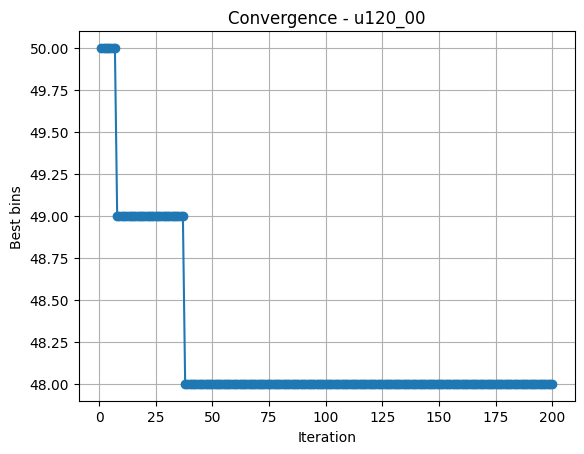

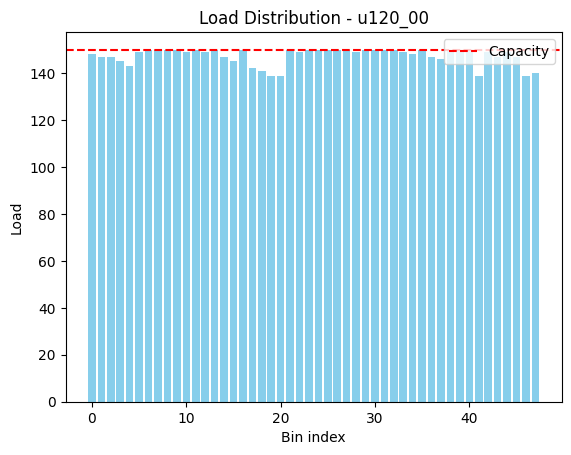


 Running instance: u120_01
Iteration 1/200 -> Best bins: 49
Iteration 2/200 -> Best bins: 49
Iteration 3/200 -> Best bins: 49
Iteration 4/200 -> Best bins: 49
Iteration 5/200 -> Best bins: 49
Iteration 6/200 -> Best bins: 49
Iteration 7/200 -> Best bins: 49
Iteration 8/200 -> Best bins: 49
Iteration 9/200 -> Best bins: 49
Iteration 10/200 -> Best bins: 49
Iteration 11/200 -> Best bins: 49
Iteration 12/200 -> Best bins: 49
Iteration 13/200 -> Best bins: 49
Iteration 14/200 -> Best bins: 49
Iteration 15/200 -> Best bins: 49
Iteration 16/200 -> Best bins: 49
Iteration 17/200 -> Best bins: 49
Iteration 18/200 -> Best bins: 49
Iteration 19/200 -> Best bins: 49
Iteration 20/200 -> Best bins: 49
Iteration 21/200 -> Best bins: 49
Iteration 22/200 -> Best bins: 49
Iteration 23/200 -> Best bins: 49
Iteration 24/200 -> Best bins: 49
Iteration 25/200 -> Best bins: 49
Iteration 26/200 -> Best bins: 49
Iteration 27/200 -> Best bins: 49
Iteration 28/200 -> Best bins: 49
Iteration 29/200 -> Best bins

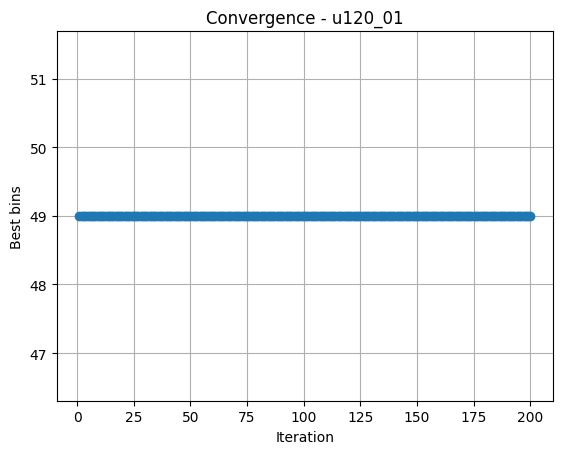

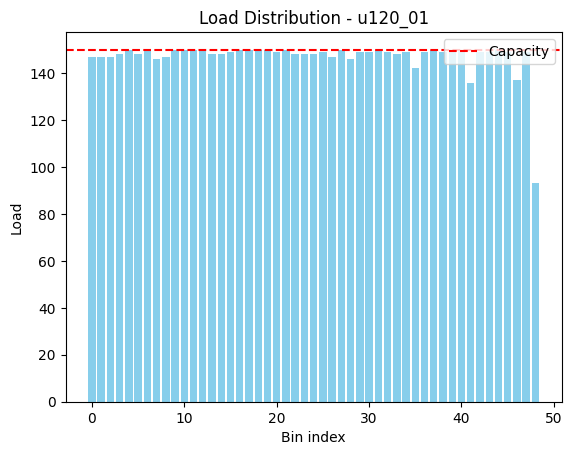


 Running instance: u120_02
Iteration 1/200 -> Best bins: 47
Iteration 2/200 -> Best bins: 47
Iteration 3/200 -> Best bins: 47
Iteration 4/200 -> Best bins: 47
Iteration 5/200 -> Best bins: 47
Iteration 6/200 -> Best bins: 47
Iteration 7/200 -> Best bins: 47
Iteration 8/200 -> Best bins: 47
Iteration 9/200 -> Best bins: 47
Iteration 10/200 -> Best bins: 47
Iteration 11/200 -> Best bins: 47
Iteration 12/200 -> Best bins: 47
Iteration 13/200 -> Best bins: 47
Iteration 14/200 -> Best bins: 47
Iteration 15/200 -> Best bins: 47
Iteration 16/200 -> Best bins: 47
Iteration 17/200 -> Best bins: 47
Iteration 18/200 -> Best bins: 47
Iteration 19/200 -> Best bins: 47
Iteration 20/200 -> Best bins: 47
Iteration 21/200 -> Best bins: 47
Iteration 22/200 -> Best bins: 46
Iteration 23/200 -> Best bins: 46
Iteration 24/200 -> Best bins: 46
Iteration 25/200 -> Best bins: 46
Iteration 26/200 -> Best bins: 46
Iteration 27/200 -> Best bins: 46
Iteration 28/200 -> Best bins: 46
Iteration 29/200 -> Best bins

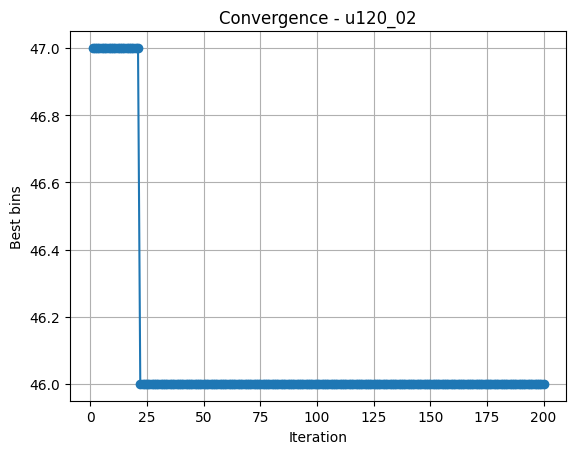

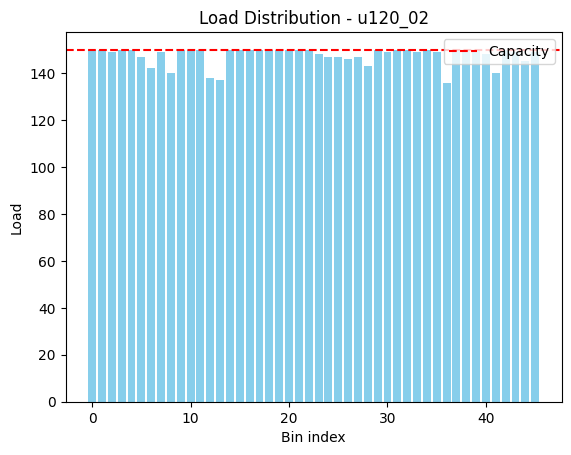


 Running instance: u120_03
Iteration 1/200 -> Best bins: 51
Iteration 2/200 -> Best bins: 51
Iteration 3/200 -> Best bins: 51
Iteration 4/200 -> Best bins: 51
Iteration 5/200 -> Best bins: 51
Iteration 6/200 -> Best bins: 51
Iteration 7/200 -> Best bins: 51
Iteration 8/200 -> Best bins: 51
Iteration 9/200 -> Best bins: 51
Iteration 10/200 -> Best bins: 51
Iteration 11/200 -> Best bins: 51
Iteration 12/200 -> Best bins: 51
Iteration 13/200 -> Best bins: 51
Iteration 14/200 -> Best bins: 51
Iteration 15/200 -> Best bins: 51
Iteration 16/200 -> Best bins: 51
Iteration 17/200 -> Best bins: 51
Iteration 18/200 -> Best bins: 50
Iteration 19/200 -> Best bins: 50
Iteration 20/200 -> Best bins: 50
Iteration 21/200 -> Best bins: 50
Iteration 22/200 -> Best bins: 50
Iteration 23/200 -> Best bins: 50
Iteration 24/200 -> Best bins: 50
Iteration 25/200 -> Best bins: 50
Iteration 26/200 -> Best bins: 50
Iteration 27/200 -> Best bins: 50
Iteration 28/200 -> Best bins: 50
Iteration 29/200 -> Best bins

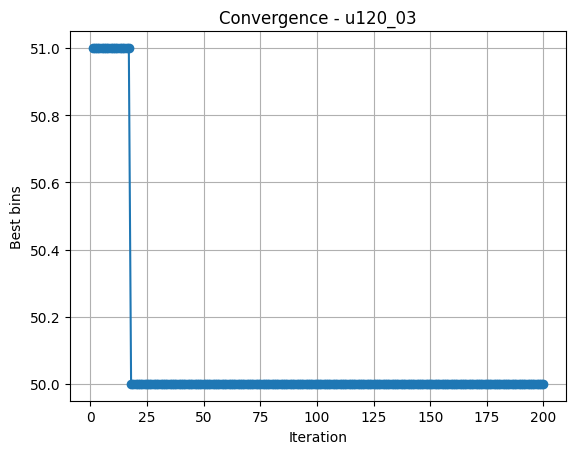

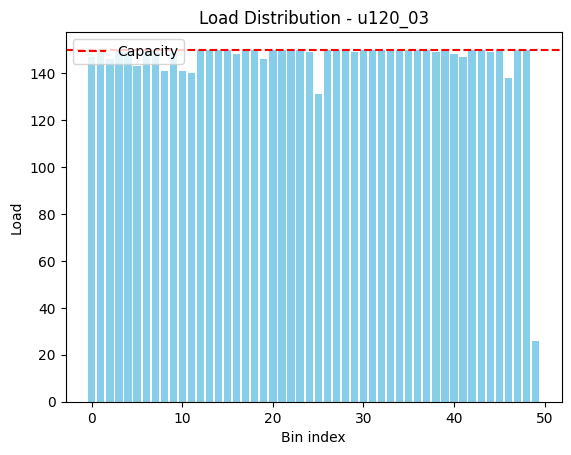


 Running instance: u120_04
Iteration 1/200 -> Best bins: 51
Iteration 2/200 -> Best bins: 51
Iteration 3/200 -> Best bins: 51
Iteration 4/200 -> Best bins: 51
Iteration 5/200 -> Best bins: 51
Iteration 6/200 -> Best bins: 51
Iteration 7/200 -> Best bins: 51
Iteration 8/200 -> Best bins: 51
Iteration 9/200 -> Best bins: 51
Iteration 10/200 -> Best bins: 51
Iteration 11/200 -> Best bins: 51
Iteration 12/200 -> Best bins: 51
Iteration 13/200 -> Best bins: 51
Iteration 14/200 -> Best bins: 51
Iteration 15/200 -> Best bins: 50
Iteration 16/200 -> Best bins: 50
Iteration 17/200 -> Best bins: 50
Iteration 18/200 -> Best bins: 50
Iteration 19/200 -> Best bins: 50
Iteration 20/200 -> Best bins: 50
Iteration 21/200 -> Best bins: 50
Iteration 22/200 -> Best bins: 50
Iteration 23/200 -> Best bins: 50
Iteration 24/200 -> Best bins: 50
Iteration 25/200 -> Best bins: 50
Iteration 26/200 -> Best bins: 50
Iteration 27/200 -> Best bins: 50
Iteration 28/200 -> Best bins: 50
Iteration 29/200 -> Best bins

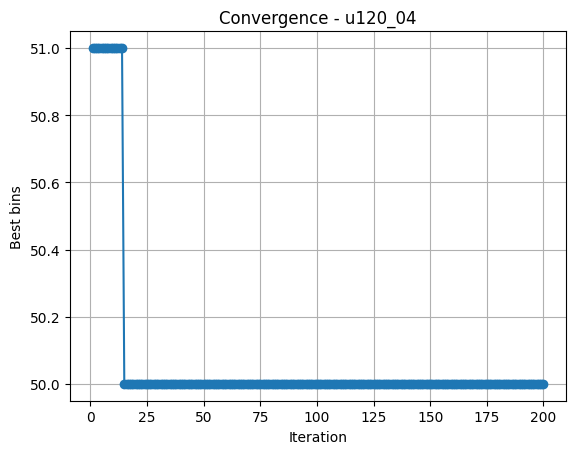

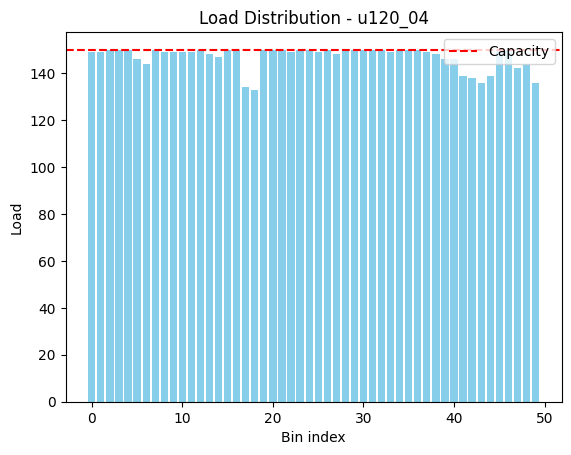


 Running instance: u120_05
Iteration 1/200 -> Best bins: 49
Iteration 2/200 -> Best bins: 49
Iteration 3/200 -> Best bins: 49
Iteration 4/200 -> Best bins: 49
Iteration 5/200 -> Best bins: 49
Iteration 6/200 -> Best bins: 49
Iteration 7/200 -> Best bins: 49
Iteration 8/200 -> Best bins: 49
Iteration 9/200 -> Best bins: 49
Iteration 10/200 -> Best bins: 49
Iteration 11/200 -> Best bins: 49
Iteration 12/200 -> Best bins: 49
Iteration 13/200 -> Best bins: 49
Iteration 14/200 -> Best bins: 49
Iteration 15/200 -> Best bins: 49
Iteration 16/200 -> Best bins: 49
Iteration 17/200 -> Best bins: 49
Iteration 18/200 -> Best bins: 49
Iteration 19/200 -> Best bins: 49
Iteration 20/200 -> Best bins: 49
Iteration 21/200 -> Best bins: 49
Iteration 22/200 -> Best bins: 49
Iteration 23/200 -> Best bins: 49
Iteration 24/200 -> Best bins: 49
Iteration 25/200 -> Best bins: 49
Iteration 26/200 -> Best bins: 49
Iteration 27/200 -> Best bins: 49
Iteration 28/200 -> Best bins: 49
Iteration 29/200 -> Best bins

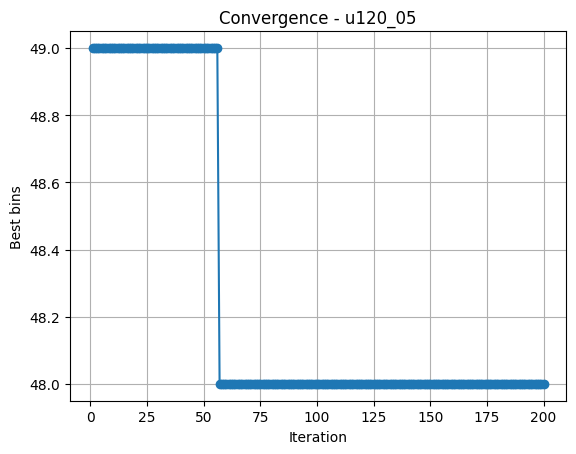

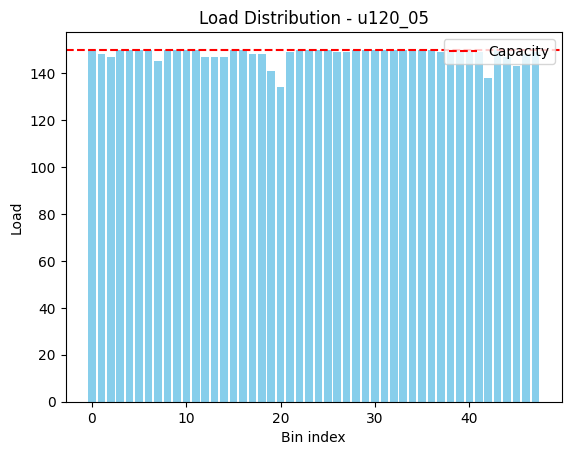


 Running instance: u120_06
Iteration 1/200 -> Best bins: 49
Iteration 2/200 -> Best bins: 49
Iteration 3/200 -> Best bins: 49
Iteration 4/200 -> Best bins: 49
Iteration 5/200 -> Best bins: 49
Iteration 6/200 -> Best bins: 49
Iteration 7/200 -> Best bins: 49
Iteration 8/200 -> Best bins: 49
Iteration 9/200 -> Best bins: 49
Iteration 10/200 -> Best bins: 49
Iteration 11/200 -> Best bins: 49
Iteration 12/200 -> Best bins: 49
Iteration 13/200 -> Best bins: 49
Iteration 14/200 -> Best bins: 49
Iteration 15/200 -> Best bins: 49
Iteration 16/200 -> Best bins: 49
Iteration 17/200 -> Best bins: 49
Iteration 18/200 -> Best bins: 49
Iteration 19/200 -> Best bins: 49
Iteration 20/200 -> Best bins: 49
Iteration 21/200 -> Best bins: 49
Iteration 22/200 -> Best bins: 49
Iteration 23/200 -> Best bins: 49
Iteration 24/200 -> Best bins: 49
Iteration 25/200 -> Best bins: 49
Iteration 26/200 -> Best bins: 49
Iteration 27/200 -> Best bins: 49
Iteration 28/200 -> Best bins: 49
Iteration 29/200 -> Best bins

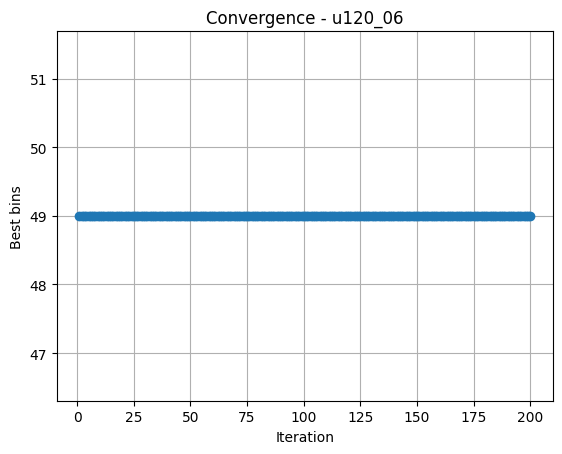

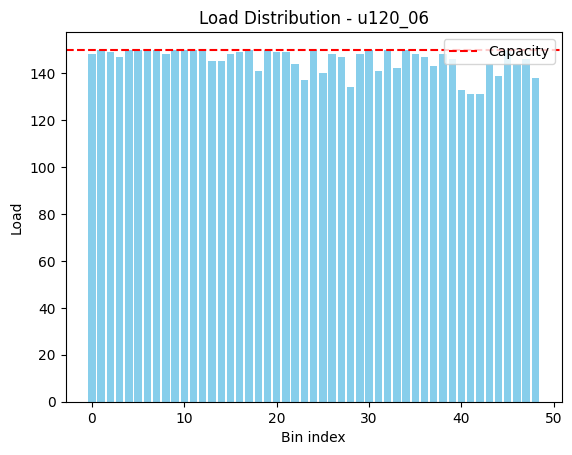


 Running instance: u120_07
Iteration 1/200 -> Best bins: 50
Iteration 2/200 -> Best bins: 50
Iteration 3/200 -> Best bins: 50
Iteration 4/200 -> Best bins: 50
Iteration 5/200 -> Best bins: 50
Iteration 6/200 -> Best bins: 50
Iteration 7/200 -> Best bins: 50
Iteration 8/200 -> Best bins: 50
Iteration 9/200 -> Best bins: 50
Iteration 10/200 -> Best bins: 50
Iteration 11/200 -> Best bins: 50
Iteration 12/200 -> Best bins: 50
Iteration 13/200 -> Best bins: 50
Iteration 14/200 -> Best bins: 50
Iteration 15/200 -> Best bins: 50
Iteration 16/200 -> Best bins: 50
Iteration 17/200 -> Best bins: 50
Iteration 18/200 -> Best bins: 50
Iteration 19/200 -> Best bins: 50
Iteration 20/200 -> Best bins: 50
Iteration 21/200 -> Best bins: 50
Iteration 22/200 -> Best bins: 50
Iteration 23/200 -> Best bins: 50
Iteration 24/200 -> Best bins: 50
Iteration 25/200 -> Best bins: 50
Iteration 26/200 -> Best bins: 50
Iteration 27/200 -> Best bins: 50
Iteration 28/200 -> Best bins: 50
Iteration 29/200 -> Best bins

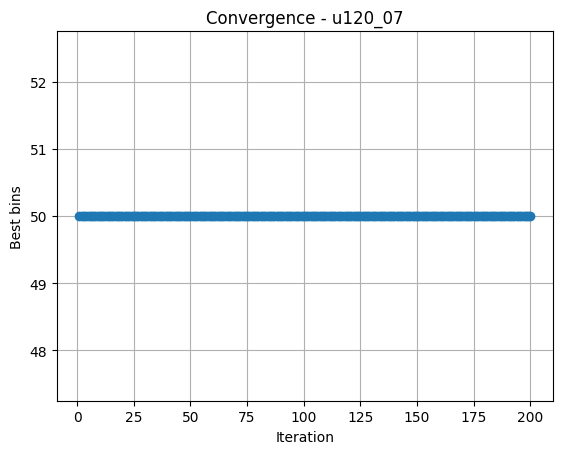

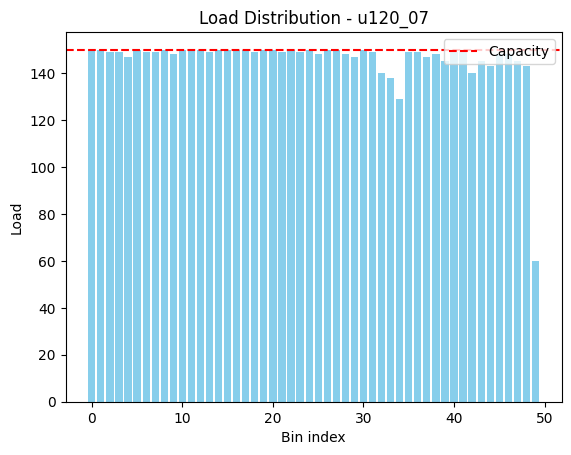


Summary Table
  Instance  Best Known  ACO Bins  Unused Space  Runtime (s)
0  u120_00          48        48           122       12.241
1  u120_01          49        49           145       10.387
2  u120_02          46        46           106       10.442
3  u120_03          49        50           215       12.664
4  u120_04          50        50           146       11.897
5  u120_05          48        48            78       12.653
6  u120_06          48        49           213       11.572
7  u120_07          49        50           205       10.227


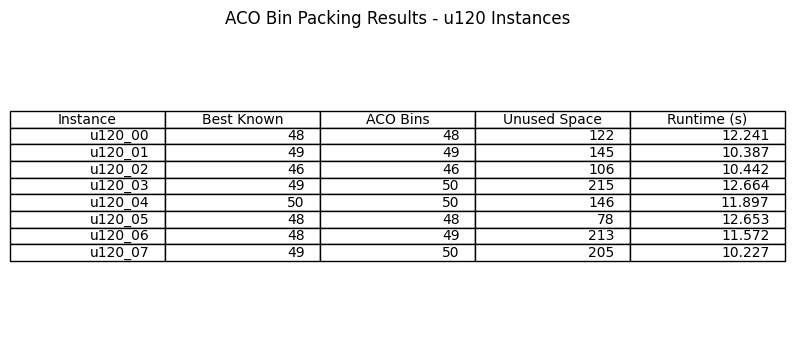

In [9]:
class AntColony:
   def __init__(self, sizes, capacity, n_ants, n_best, n_iterations, decay, alpha, beta, ph_depo, R_max, temperature, shuffle_prob):

    self.sizes = sizes
    self.capacity = capacity
    self.n = len(sizes)

    self.n_ants = n_ants
    self.n_best = n_best
    self.n_iterations = n_iterations
    self.decay = decay
    self.alpha = alpha
    self.beta = beta
    self.ph_depo = ph_depo
    self.R_max = R_max

    # Pheromone levels for ranks 0 to R_max
    self.pheromone = np.ones(R_max + 1)

    # Temperature for scaling probabilities
    self.temperature = temperature

    # Probability to shuffle item order
    self.shuffle_prob = shuffle_prob

    # Helper functions

   def heuristic(self, residual):
      """Calculate heuristic value based on residual space."""
      return 1.0 / (1.0 + residual)

   def choice_probabilities(self, feasible_bins, new_residual):
      """Calculate choice probabilities for feasible bins and a new bin."""
      options = []

      # Existing bins
      for rank, residual in feasible_bins:
        limited_rank = min(rank, self.R_max)
        pheromone_strength = self.pheromone[limited_rank] ** self.alpha
        heuristic_value = self.heuristic(residual) ** self.beta
        options.append((limited_rank, pheromone_strength * heuristic_value))

      # New bin
      pheromone_new = self.pheromone[0] ** self.alpha
      heuristic_new = self.heuristic(new_residual) ** self.beta
      options.append((0, pheromone_new * heuristic_new))

      # Convert to numpy array for temperature scaling
      ranks, scores = zip(*options)
      scores = np.array(scores)

      probs = scores ** (1 / self.temperature)
      probs /= probs.sum()
      return list(zip(ranks, probs))

   def sample_rank(self, probabilities):
      """Choose a rank based on the given probabilities."""
      random_value = np.random.random()
      running_total = 0.0
      for rank, prob in probabilities:
        running_total += prob
        if random_value <= running_total:
          return rank
      return probabilities[-1][0]

   def construct_solution(self):
      """Construct a solution for one ant."""
      bins = [] # List of bins with items
      loads = [] # Total load of each bin
      ranks_used = [] # Track ranks chosen for later pheromone update

      order=list(range(self.n))
      if np.random.random() < self.shuffle_prob:
        np.random.shuffle(order)
      else:
        order.sort(key=lambda i: -self.sizes[i])

      for item in order:
        item_size = self.sizes[item]

        # Find feasible bins
        feasible = []
        for bin_index in range(len(loads)):
          if loads[bin_index] + item_size <= self.capacity:
            residual_after = self.capacity - (loads[bin_index] + item_size)
            feasible.append((bin_index, residual_after))
        feasible_ranked = [(i + 1, res) for i, (_, res) in enumerate(sorted(feasible,  key=lambda x: x[1]))]

        # Calculate probabilities and sample rank
        new_residual = self.capacity - item_size
        probabilities = self.choice_probabilities(feasible_ranked, new_residual)
        chosen_rank = self.sample_rank(probabilities)
        ranks_used.append(chosen_rank)

        # Place item
        if chosen_rank == 0:
           bins.append([item])
           loads.append(item_size)
        else:
          index = min(chosen_rank - 1, len(feasible) - 1)
          bin_index = feasible[index][0]
          bins[bin_index].append(item)
          loads[bin_index] += item_size
      
      num_bins = len(bins)
      total_unused = num_bins * self.capacity - sum(loads)
      return bins, loads, ranks_used, num_bins, total_unused

   def run(self):
    """Execute the ACO algorithm to solve the bin packing problem."""
    best_solution = None
    best_bins = float("inf")
    best_progress = []

    for iteration in range(self.n_iterations):
      all_solutions = []
      for _ in range(self.n_ants):
        bins, loads, ranks_used, num_bins, total_unused = self.construct_solution()
        all_solutions.append((bins, loads, ranks_used, num_bins, total_unused))

      # Sort by number of bins used and unused space
      all_solutions.sort(key=lambda x: (x[3], x[4]))

      # Evaporate pheromone
      self.pheromone *= self.decay

      # Deposit pheromone for the best solutions
      for i in range(self.n_best):
        bins, loads, ranks_used, num_bins, total_unused = all_solutions[i]
        for r in ranks_used:
          self.pheromone[r] += self.ph_depo / num_bins

      # Track the best solution found so far
      best_iteration = all_solutions[0]
      if best_iteration[3] < best_bins:
        best_bins = best_iteration[3]
        best_solution = best_iteration
      best_progress.append(best_bins)

      print(f"Iteration {iteration+1}/{self.n_iterations} -> Best bins: {best_bins}")

    print("\nBest overall solution used", best_bins, "bins")
    bins, loads, _, _, _ = best_solution
    for i, (b, load) in enumerate(zip(bins, loads)):
      print(f" Bin {i}: load={load}, items={[self.sizes[j] for j in b]}")

    return  best_solution, best_progress

# Load JSON dataset
with open("binpack_u120.json", "r") as f:
    problems = json.load(f)

results = []

# Run ACO on each problem instance
for prob in problems:
    print(f"\n Running instance: {prob['name']}")
    sizes = prob["items"]
    capacity = prob["capacity"]
    best_known = prob["best"]

    start_time = time.time()

    ant_colony = AntColony(
        sizes, capacity,
        n_ants=50,
        n_best=5,
        n_iterations=200,
        decay=1,
        alpha=3,
        beta=1,
        ph_depo = 1,
        R_max=10,
        temperature=2.0,
        shuffle_prob=0.3
    )

    best_solution, progress = ant_colony.run()
    bins, loads, ranks_used, num_bins, total_unused = best_solution

    end_time = time.time()
    runtime = round(end_time - start_time, 3)

    plt.figure()
    plt.plot(range(1, len(progress) + 1), progress, marker='o')
    plt.xlabel("Iteration")
    plt.ylabel("Best bins")
    plt.title(f"Convergence - {prob['name']}")
    plt.grid(True)
    plt.show()

    plt.figure()
    plt.bar(range(len(loads)), loads, color='skyblue')
    plt.axhline(capacity, color='red', linestyle='--', label='Capacity')
    plt.xlabel("Bin index")
    plt.ylabel("Load")
    plt.title(f"Load Distribution - {prob['name']}")
    plt.legend()
    plt.show()

    # Save results for summary table
    results.append({
        "Instance": prob["name"],
        "Best Known": best_known,
        "ACO Bins": num_bins,
        "Unused Space": total_unused,
        "Runtime (s)": runtime
    })

# Display summary table
df = pd.DataFrame(results)
print("\nSummary Table")
print(df)

# Plot table using matplotlib
fig, ax = plt.subplots(figsize=(10, 4))
ax.axis('tight')
ax.axis('off')
table_data = df.values
column_labels = df.columns
ax.table(cellText=table_data, colLabels=column_labels, loc='center')
plt.title("ACO Bin Packing Results - u120 Instances")
plt.show()
